In [ ]:
!apt-get update
!apt-get install -y tshark
!pip install scikit-learn pandas numpy seaborn matplotlib pyshark

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,936 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,880 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,615 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,794 kB]
Get:14 http://archive

## Feature Selection and Extraction

In [ ]:
import pyshark
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from tqdm import tqdm
import warnings
import asyncio # Import asyncio
import nest_asyncio # Import nest_asyncio

warnings.filterwarnings("ignore")

# Set the event loop policy to allow nested event loops
asyncio.set_event_loop_policy(asyncio.DefaultEventLoopPolicy())
nest_asyncio.apply() # Apply nest_asyncio to allow nested event loops

PCAP_FILES = [
    "capture_loss0.pcap",
    "capture_loss10.pcap",
    "capture_loss15.pcap",
    "capture_loss5.pcap",
    "capture_loss20.pcap"
]

OUTPUT_CSV = "features_selected.csv"
TOP_K = 10
PCA_COMPONENTS = 5


def parse_pcap(pcap_file):
    print(f"\n[*] Parsing {pcap_file} ...")
    cap = pyshark.FileCapture(pcap_file, display_filter="tcp")

    def to_int(val):
        try:
            return int(val)
        except:
            return 1 if str(val).strip().lower() == "true" else 0

    records = []

    for pkt in tqdm(cap, desc=f"Packets ({pcap_file})", unit="pkt"):
        try:
            tcp = pkt.tcp
            ip = pkt.ip

            record = {
                "ip_ttl": int(ip.ttl),
                "ip_len": int(ip.len),
                "ip_proto": int(ip.proto),

                "tcp_srcport": int(tcp.srcport),
                "tcp_dstport": int(tcp.dstport),
                "tcp_seq": int(tcp.seq),
                "tcp_ack": int(tcp.ack),
                "tcp_len": int(tcp.len),
                "tcp_window_size": int(tcp.window_size_value),
                "tcp_hdr_len": int(tcp.hdr_len),

                "flag_syn": to_int(tcp.flags_syn),
                "flag_ack": to_int(tcp.flags_ack),
                "flag_fin": to_int(tcp.flags_fin),
                "flag_rst": to_int(tcp.flags_reset),
                "flag_push": to_int(tcp.flags_push),
                "flag_urg": to_int(tcp.flags_urg),

                "frame_time_delta": float(pkt.frame_info.time_delta),
                "frame_time_epoch": float(pkt.frame_info.time_epoch),

                # Label
                "packet_loss": 1 if hasattr(tcp, "analysis_retransmission") else 0,
            }

            records.append(record)

        except AttributeError:
            continue

    cap.close()

    df = pd.DataFrame(records)

    if df.empty:
        print(f"[!] No TCP packets found in {pcap_file}")
        return df

    df["frame_time_epoch"] = df["frame_time_epoch"] - df["frame_time_epoch"].min()

    print(f"[+] {pcap_file}: {len(df)} packets | Loss: {df['packet_loss'].sum()}")

    return df

def parse_multiple_pcaps(pcap_files):
    all_dfs = []

    for i, file in enumerate(pcap_files):
        df = parse_pcap(file)

        if not df.empty:
            df["file_id"] = i
            df["source_file"] = file
            all_dfs.append(df)

    if not all_dfs:
        raise ValueError("❌ No valid data extracted from PCAP files.")

    combined_df = pd.concat(all_dfs, ignore_index=True)

    print("\n[+] COMBINED DATASET SUMMARY")
    print(f"Total packets : {len(combined_df)}")
    print(f"Columns       : {len(combined_df.columns)}")
    print(f"Loss distribution:\n{combined_df['packet_loss'].value_counts()}")

    return combined_df


def engineer_features(df):
    df = df.sort_values(["file_id", "frame_time_epoch"]).reset_index(drop=True)

    steps = [
        ("Inter-arrival time", lambda d: d.groupby("file_id")["frame_time_epoch"].diff().fillna(0)),
        ("Sequence delta", lambda d: d.groupby("file_id")["tcp_seq"].diff().fillna(0)),
        ("ACK delta", lambda d: d.groupby("file_id")["tcp_ack"].diff().fillna(0)),
        ("Rolling mean len", lambda d: d.groupby("file_id")["tcp_len"].rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)),
        ("Rolling std len", lambda d: d.groupby("file_id")["tcp_len"].rolling(5, min_periods=1).std().fillna(0).reset_index(level=0, drop=True)),
        ("Rolling loss rate", lambda d: d.groupby("file_id")["packet_loss"].rolling(10, min_periods=1).mean().reset_index(level=0, drop=True)),
    ]

    col_names = ["iat", "seq_delta", "ack_delta",
                 "rolling_mean_len", "rolling_std_len", "rolling_loss_rate"]

    for (desc, fn), col in tqdm(zip(steps, col_names), total=len(steps),
                               desc="Engineering features", unit="feature"):
        df[col] = fn(df)

    return df


def select_features(df, top_k=TOP_K, n_pca=PCA_COMPONENTS):
    label_col = "packet_loss"
    drop_cols = [label_col, "frame_time_epoch", "source_file", "file_id"]

    X = df.drop(columns=drop_cols, errors="ignore").fillna(0)
    y = df[label_col]

    feature_names = X.columns.tolist()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # SelectKBest
    selector = SelectKBest(score_func=f_classif, k=min(top_k, len(feature_names)))
    selector.fit(X_scaled, y)
    kbest_scores = pd.Series(selector.scores_, index=feature_names).sort_values(ascending=False)
    kbest_features = kbest_scores.head(top_k).index.tolist()

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled, y)
    rf_scores = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    rf_features = rf_scores.head(top_k).index.tolist()

    # PCA
    pca = PCA(n_components=min(n_pca, X_scaled.shape[1]))
    pca.fit(X_scaled)
    explained = pca.explained_variance_ratio_

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    pca_features = loadings.abs().max(axis=1).sort_values(ascending=False).head(top_k).index.tolist()

    print("\n[+] Feature Selection Results")
    print("KBest:", kbest_features)
    print("RF   :", rf_features)
    print("PCA  :", pca_features)
    print("Explained variance:", np.round(explained, 3), "Total:", explained.sum())

    return {
        "kbest_features": kbest_features,
        "rf_features": rf_features,
        "pca_features": pca_features,
        "feature_names": feature_names,
        "scaler": scaler,
    }


def export_csv(df, results, output_path=OUTPUT_CSV):
    selected = list(set(
        results["kbest_features"] +
        results["rf_features"] +
        results["pca_features"]
    ))

    selected = [c for c in selected if c in df.columns]

    print(f"\n[*] Exporting {len(selected)} features...")

    out_df = df[selected].copy()
    out_df["packet_loss"] = df["packet_loss"].values

    out_df.to_csv(output_path, index=False)

    print(f"[+] Saved dataset → {output_path}")


if __name__ == "__main__":
    df = parse_multiple_pcaps(PCAP_FILES)

    df = engineer_features(df)

    results = select_features(df)

    export_csv(df, results)

    print("\n✅ DONE! Multi-PCAP dataset ready for training.")


[*] Parsing capture_loss0.pcap ...


Packets (capture_loss0.pcap): 63907pkt [09:37, 110.61pkt/s]


[+] capture_loss0.pcap: 63907 packets | Loss: 8

[*] Parsing capture_loss10.pcap ...


Packets (capture_loss10.pcap): 3556pkt [00:28, 125.46pkt/s]


[+] capture_loss10.pcap: 3556 packets | Loss: 304

[*] Parsing capture_loss15.pcap ...


...

[+] capture_loss5.pcap: 22904 packets | Loss: 701

[*] Parsing capture_loss20.pcap ...


Packets (capture_loss20.pcap): 498pkt [00:04, 116.63pkt/s]


[+] capture_loss20.pcap: 498 packets | Loss: 91

[+] COMBINED DATASET SUMMARY
Total packets : 91518
Columns       : 21
Loss distribution:
packet_loss
0    90336
1     1182
Name: count, dtype: int64


Engineering features: 100%|██████████| 6/6 [00:00<00:00, 64.32feature/s]



[+] Feature Selection Results
KBest: ['rolling_loss_rate', 'frame_time_delta', 'iat', 'rolling_std_len', 'tcp_dstport', 'flag_fin', 'tcp_ack', 'flag_ack', 'flag_syn', 'flag_push']
RF   : ['rolling_loss_rate', 'iat', 'frame_time_delta', 'seq_delta', 'tcp_seq', 'tcp_srcport', 'ack_delta', 'rolling_std_len', 'rolling_mean_len', 'ip_len']
PCA  : ['flag_rst', 'flag_ack', 'iat', 'frame_time_delta', 'flag_syn', 'rolling_std_len', 'rolling_loss_rate', 'tcp_window_size', 'ip_len', 'tcp_len']
Explained variance: [0.391 0.109 0.097 0.089 0.053] Total: 0.7393340563790389

[*] Exporting 19 features...
[+] Saved dataset → features_selected.csv

✅ DONE! Multi-PCAP dataset ready for training.


## **Essential Data Processing**

Data-Cleaning and Pre-Processing

In [ ]:
out_df = pd.read_csv("features_selected.csv")
print("Class Distribution:")
print(out_df["packet_loss"].value_counts())
print("\nPercentage:")
print(out_df["packet_loss"].value_counts(normalize=True) * 100)

Class Distribution:
packet_loss
0    90336
1     1182
Name: count, dtype: int64

Percentage:
packet_loss
0    98.708451
1     1.291549
Name: proportion, dtype: float64


Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

target = "packet_loss"
features = [col for col in out_df.columns if col != target]

X = out_df[features]
y = out_df[target]

X_train_bal, X_test_bal, y_train_bal, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Balance Dataset with SMOTE

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_bal, y_train_bal)

print("After SMOTE:")
print(pd.Series(y_train_bal).value_counts())

After SMOTE:
packet_loss
0    72268
1    72268
Name: count, dtype: int64


Feature Scalling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)

X_test_scaled = scaler.transform(X_test_bal)

In [ ]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

## **Machine Learning Models Build and Train**

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_pca, y_train_bal)

log_pred = log_model.predict(X_test_pca)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9153190559440559

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     18068
           1       0.12      0.86      0.21       236

    accuracy                           0.92     18304
   macro avg       0.56      0.89      0.58     18304
weighted avg       0.99      0.92      0.95     18304



Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_pca, y_train_bal)

rf_pred = rf_model.predict(X_test_pca)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9780922202797203

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     18068
           1       0.33      0.70      0.45       236

    accuracy                           0.98     18304
   macro avg       0.67      0.84      0.72     18304
weighted avg       0.99      0.98      0.98     18304



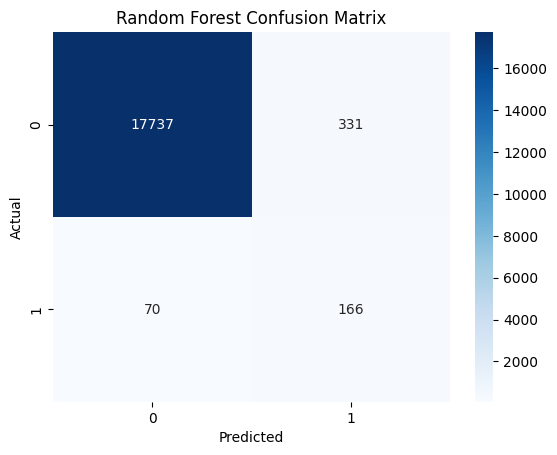

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

Support Vector Machine(SVM)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import joblib

scaler = StandardScaler()

X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_bal)

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_bal_scaled)
X_test_pca = pca.transform(X_test_scaled)

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

['pca.pkl']

SVM Accuracy: 0.9225305944055944

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.92      0.96     18068
           1       0.13      0.92      0.23       236

    accuracy                           0.92     18304
   macro avg       0.57      0.92      0.60     18304
weighted avg       0.99      0.92      0.95     18304



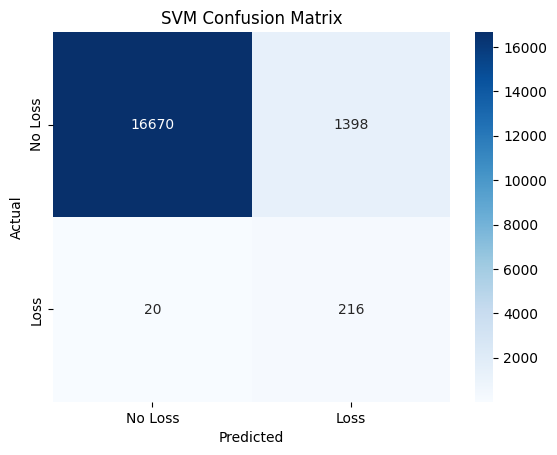

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True)

svm_model.fit(X_train_pca, y_train_bal)

svm_pred = svm_model.predict(X_test_pca)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Loss", "Loss"],
            yticklabels=["No Loss", "Loss"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

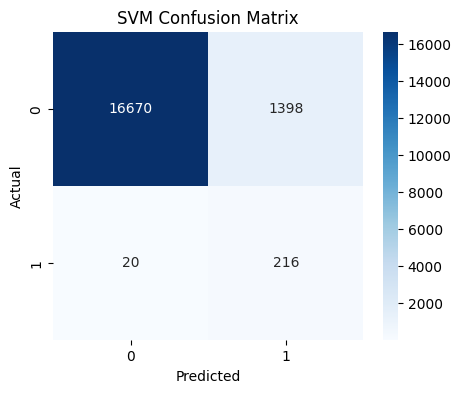

In [ ]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_pca, y_train_bal)

xgb_pred = xgb_model.predict(X_test_pca)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.967930506993007

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     18068
           1       0.27      0.86      0.41       236

    accuracy                           0.97     18304
   macro avg       0.63      0.92      0.70     18304
weighted avg       0.99      0.97      0.98     18304



Neural Networks

In [ ]:
!pip install tensorflow

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9209 - loss: 0.2206 - val_accuracy: 0.9683 - val_loss: 0.1755
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9403 - loss: 0.1673 - val_accuracy: 0.9682 - val_loss: 0.1498
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9428 - loss: 0.1580 - val_accuracy: 0.9653 - val_loss: 0.1538
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9450 - loss: 0.1529 - val_accuracy: 0.9686 - val_loss: 0.1458
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9475 - loss: 0.1464 - val_accuracy: 0.9674 - val_loss: 0.1313
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9502 - loss: 0.1400 - val_accuracy: 0.9764 - val_loss: 0.1041
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9549 - loss: 0.1280 - val_accuracy: 0.9745 - val_loss: 0.0971
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9601 - loss: 0.1160 - val_accuracy: 

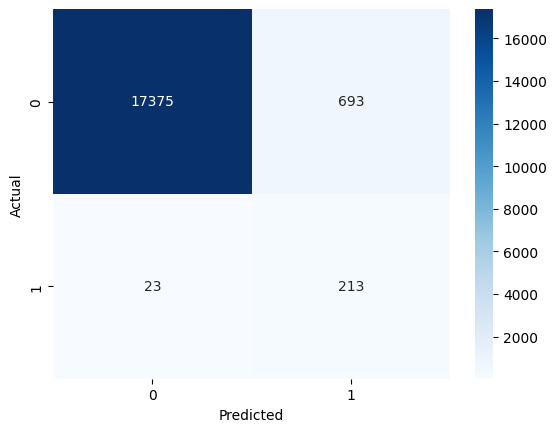

Neural Network model saved successfully.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = tf.keras.Sequential([

    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_pca.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_pca,
    y_train_bal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_accuracy = model.evaluate(X_test_pca, y_test)

print("Neural Network Test Accuracy:", test_accuracy)

y_pred_prob = model.predict(X_test_pca)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

model.save("neural_network_model.h5")

print("Neural Network model saved successfully.")

Save and Download Models

In [ ]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(xgb_model, "xgboost_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("All models saved successfully.")

All models saved successfully.


In [ ]:
from google.colab import files

files.download("logistic_model.pkl")
files.download("random_forest_model.pkl")
files.download("svm_model.pkl")
files.download("xgboost_model.pkl")
files.download("neural_network_model.h5")
files.download("scaler.pkl")
files.download("pca.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Test Models for Un-Seen Inputs**

In [ ]:
import joblib
import tensorflow as tf

log_model = joblib.load("logistic_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")
svm_model = joblib.load("svm_model.pkl")
xgb_model = joblib.load("xgboost_model.pkl")

scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")

try:
    nn_model = tf.keras.models.load_model(
        "neural_network_model.h5",
        compile=False
    )
    print("✅ Neural Network loaded")
except Exception as e:
    print("⚠️ Neural Network failed to load:", e)
    nn_model = None

print("✅ All models and preprocessing objects loaded successfully.")

✅ Neural Network loaded
✅ All models and preprocessing objects loaded successfully.


In [ ]:
new_packet = [[
    # Features must match the training features (19 features)
    # Order: ['flag_syn', 'tcp_window_size', 'tcp_len', 'tcp_seq', 'ip_len',
    #         'frame_time_delta', 'tcp_srcport', 'rolling_std_len', 'rolling_loss_rate',
    #         'flag_push', 'tcp_dstport', 'tcp_ack', 'flag_rst', 'flag_fin',
    #         'seq_delta', 'iat', 'rolling_mean_len', 'flag_ack', 'ack_delta']

    0,                  # flag_syn
    8000,               # tcp_window_size
    1460,               # tcp_len
    1200,               # tcp_seq
    1500,               # ip_len
    0.002,              # frame_time_delta (low delay)
    5000,               # tcp_srcport
    0.0,                # rolling_std_len
    0.0,                # rolling_loss_rate
    0,                  # flag_push
    80,                 # tcp_dstport (HTTP traffic)
    1200,               # tcp_ack
    0,                  # flag_rst
    0,                  # flag_fin
    0.0,                # seq_delta
    0.002,              # iat (inter-arrival time)
    1460.0,             # rolling_mean_len
    0,                  # flag_ack
    0.0                 # ack_delta
]]

Test SVM

In [ ]:
new_scaled = scaler.transform(new_packet)

new_pca = pca.transform(new_scaled)

svm_prediction = svm_model.predict(new_pca)
log_prediction = log_model.predict(new_pca)

print("SVM:", "Packet Lost" if svm_prediction[0] == 1 else "No Loss")
print("Logistic:", "Packet Lost" if log_prediction[0] == 1 else "No Loss")

SVM: No Loss
Logistic: Packet Lost


In [ ]:
new_scaled = scaler.transform(new_packet)

new_pca = pca.transform(new_scaled)

rf_prediction = rf_model.predict(new_pca)
xgb_prediction = xgb_model.predict(new_pca)

print("Random Forest:", "Packet Lost" if rf_prediction[0] == 1 else "No Loss")
print("XGBoost:", "Packet Lost" if xgb_prediction[0] == 1 else "No Loss")

Random Forest: Packet Lost
XGBoost: Packet Lost


In [ ]:
def predict_packet(packet):
    import numpy as np

    packet = np.array(packet)

    scaled = scaler.transform(packet)

    pca_features = pca.transform(scaled)

    results = {}

    results["Logistic"] = log_model.predict(pca_features)[0]
    results["SVM"] = svm_model.predict(pca_features)[0]
    results["RandomForest"] = rf_model.predict(pca_features)[0]
    results["XGBoost"] = xgb_model.predict(pca_features)[0]

    if nn_model:
        prob = nn_model.predict(pca_features, verbose=0)[0][0]
        results["NeuralNet"] = int(prob > 0.5)
        results["NN_Prob"] = float(prob)
    else:
        results["NeuralNet"] = 0
        results["NN_Prob"] = 0.0

    for model, pred in results.items():
        if model != "NN_Prob":
            print(f"{model}: {'Packet Lost' if pred==1 else 'No Loss'}")

    if "NN_Prob" in results:
        print(f"NN Probability: {results['NN_Prob']:.4f}")

    return results

In [ ]:
new_packet = [[
    80,                 # dst_port
    0.08,               # inter_arrival_time (high delay)
    0.6,                # rolling_loss_rate (HIGH)
    3,                  # duplicate_ack_count (strong signal)
    34813,              # seq
    1,                  # duplicate_ack
    0.02,               # jitter (high)
    29,                 # ack mismatch
    0.25,               # rtt_estimate (high latency)
    1,                  # retransmission
    0.5,                # retransmission_rate
    1,                  # lost_segment
    5000,               # src_port
    1.771739e9
]]

In [ ]:
i = 1

# Features expected by the scaler and models (19 features):
# ['flag_syn', 'tcp_window_size', 'tcp_len', 'tcp_seq', 'ip_len',
#  'frame_time_delta', 'tcp_srcport', 'rolling_std_len', 'rolling_loss_rate',
#  'flag_push', 'tcp_dstport', 'tcp_ack', 'flag_rst', 'flag_fin',
#  'seq_delta', 'iat', 'rolling_mean_len', 'flag_ack', 'ack_delta']

for sample in [

    # 🟢 NO LOSS (Stable network) - 19 features
    [0, 65535, 1000, 10000, 1040, 0.001, 50000, 5.0, 0.0, 0, 80, 20000, 0, 0, 1000.0, 0.001, 1000.0, 1, 1000.0],
    [0, 65535, 1200, 11000, 1240, 0.0015, 50002, 7.0, 0.0, 0, 443, 21000, 0, 0, 1200.0, 0.0015, 1100.0, 1, 1200.0],
    [0, 65535, 800, 12000, 840, 0.0008, 50003, 3.0, 0.0, 0, 22, 22000, 0, 0, 800.0, 0.0008, 900.0, 1, 800.0],

    # 🟡 BORDERLINE (Mild instability) - 19 features
    [0, 60000, 700, 15000, 740, 0.01, 50004, 20.0, 0.1, 0, 80, 25000, 0, 0, 600.0, 0.01, 750.0, 1, 600.0],
    [0, 60000, 900, 15500, 940, 0.015, 50005, 25.0, 0.15, 0, 443, 25500, 0, 0, 700.0, 0.015, 800.0, 1, 700.0],

    # 🔴 PACKET LOSS (Strong signals) - 19 features
    # Example: Retransmission with 0 sequence/ack delta, high loss rate
    [0, 50000, 500, 10000, 540, 0.05, 50006, 50.0, 0.5, 1, 80, 20000, 0, 0, 0.0, 0.05, 700.0, 1, 0.0],
    [0, 50000, 600, 10000, 640, 0.06, 50007, 55.0, 0.6, 1, 443, 20000, 0, 0, 0.0, 0.06, 750.0, 1, 0.0],
    [0, 50000, 400, 11000, 440, 0.04, 50008, 45.0, 0.45, 1, 80, 21000, 0, 0, 0.0, 0.04, 650.0, 1, 0.0],

    # 🔴 HEAVY LOSS (Extreme case) - 19 features
    [0, 40000, 200, 10000, 240, 0.1, 50009, 100.0, 0.9, 1, 80, 20000, 0, 0, 0.0, 0.1, 400.0, 1, 0.0],
    [0, 40000, 100, 10000, 140, 0.15, 50010, 120.0, 0.95, 1, 443, 20000, 0, 0, 0.0, 0.15, 300.0, 1, 0.0],

]:
    print("Sample:", i)
    predict_packet([sample])
    print("-" * 50)
    i += 1

Sample: 1
Logistic: No Loss
SVM: No Loss
RandomForest: Packet Lost
XGBoost: Packet Lost
NeuralNet: Packet Lost
NN Probability: 0.7975
--------------------------------------------------
Sample: 2
Logistic: No Loss
SVM: No Loss
RandomForest: Packet Lost
XGBoost: Packet Lost
NeuralNet: Packet Lost
NN Probability: 0.8350
--------------------------------------------------
Sample: 3
Logistic: No Loss
SVM: No Loss
RandomForest: Packet Lost
XGBoost: Packet Lost
NeuralNet: Packet Lost
NN Probability: 0.7510
--------------------------------------------------
Sample: 4
Logistic: Packet Lost
SVM: No Loss
RandomForest: Packet Lost
XGBoost: Packet Lost
NeuralNet: Packet Lost
NN Probability: 0.9147
--------------------------------------------------
Sample: 5
Logistic: Packet Lost
SVM: No Loss
RandomForest: Packet Lost
XGBoost: Packet Lost
NeuralNet: Packet Lost
NN Probability: 0.9469
--------------------------------------------------
Sample: 6
Logistic: Packet Lost
SVM: No Loss
RandomForest: Packet L

Neural Network

In [ ]:
i = 1

for sample in [
    # Example samples - ensure 19 features in correct order
    [0, 65535, 1000, 10000, 1040, 0.001, 50000, 5.0, 0.0, 0, 80, 20000, 0, 0, 1000.0, 0.001, 1000.0, 1, 1000.0],
    [0, 65535, 1200, 11000, 1240, 0.0015, 50002, 7.0, 0.0, 0, 443, 21000, 0, 0, 1200.0, 0.0015, 1100.0, 1, 1200.0],
    [0, 65535, 800, 12000, 840, 0.0008, 50003, 3.0, 0.0, 0, 22, 22000, 0, 0, 800.0, 0.0008, 900.0, 1, 800.0],
    [0, 60000, 700, 15000, 740, 0.01, 50004, 20.0, 0.1, 0, 80, 25000, 0, 0, 600.0, 0.01, 750.0, 1, 600.0],
    [0, 60000, 900, 15500, 940, 0.015, 50005, 25.0, 0.15, 0, 443, 25500, 0, 0, 700.0, 0.015, 800.0, 1, 700.0],
    [0, 50000, 500, 10000, 540, 0.05, 50006, 50.0, 0.5, 1, 80, 20000, 0, 0, 0.0, 0.05, 700.0, 1, 0.0],
    [0, 50000, 600, 10000, 640, 0.06, 50007, 55.0, 0.6, 1, 443, 20000, 0, 0, 0.0, 0.06, 750.0, 1, 0.0],
    [0, 50000, 400, 11000, 440, 0.04, 50008, 45.0, 0.45, 1, 80, 21000, 0, 0, 0.0, 0.04, 650.0, 1, 0.0],
    [0, 40000, 200, 10000, 240, 0.1, 50009, 100.0, 0.9, 1, 80, 20000, 0, 0, 0.0, 0.1, 400.0, 1, 0.0],
    [0, 40000, 100, 10000, 140, 0.15, 50010, 120.0, 0.95, 1, 443, 20000, 0, 0, 0.0, 0.15, 300.0, 1, 0.0],
]:

    sample_array = np.array([sample])

    sample_scaled = scaler.transform(sample_array)
    sample_pca = pca.transform(sample_scaled) # Apply PCA transformation

    prob = nn_model.predict(sample_pca, verbose=0)

    prediction = (prob > 0.5).astype(int)

    print(f"Sample {i}:")
    print("Input:", sample)
    print("Prediction:", "Packet Lost" if prediction[0][0] == 1 else "No Loss")
    print("Probability of Loss:", float(prob[0][0]))
    print("-" * 40)

    i += 1

Sample 1:
Input: [0, 65535, 1000, 10000, 1040, 0.001, 50000, 5.0, 0.0, 0, 80, 20000, 0, 0, 1000.0, 0.001, 1000.0, 1, 1000.0]
Prediction: Packet Lost
Probability of Loss: 0.7975214123725891
----------------------------------------
Sample 2:
Input: [0, 65535, 1200, 11000, 1240, 0.0015, 50002, 7.0, 0.0, 0, 443, 21000, 0, 0, 1200.0, 0.0015, 1100.0, 1, 1200.0]
Prediction: Packet Lost
Probability of Loss: 0.8350149393081665
----------------------------------------
Sample 3:
Input: [0, 65535, 800, 12000, 840, 0.0008, 50003, 3.0, 0.0, 0, 22, 22000, 0, 0, 800.0, 0.0008, 900.0, 1, 800.0]
Prediction: Packet Lost
Probability of Loss: 0.750999391078949
----------------------------------------
Sample 4:
Input: [0, 60000, 700, 15000, 740, 0.01, 50004, 20.0, 0.1, 0, 80, 25000, 0, 0, 600.0, 0.01, 750.0, 1, 600.0]
Prediction: Packet Lost
Probability of Loss: 0.9147376418113708
----------------------------------------
Sample 5:
Input: [0, 60000, 900, 15500, 940, 0.015, 50005, 25.0, 0.15, 0, 443, 25500, 0

In [ ]:
i = 1

# Features expected by the scaler and models (19 features):
# ['flag_syn', 'tcp_window_size', 'tcp_len', 'tcp_seq', 'ip_len',
#  'frame_time_delta', 'tcp_srcport', 'rolling_std_len', 'rolling_loss_rate',
#  'flag_push', 'tcp_dstport', 'tcp_ack', 'flag_rst', 'flag_fin',
#  'seq_delta', 'iat', 'rolling_mean_len', 'flag_ack', 'ack_delta']

for sample, actual_label in [
    # 🟢 NO LOSS (Stable network) - 19 features
    ([0, 65535, 1000, 10000, 1040, 0.001, 50000, 5.0, 0.0, 0, 80, 20000, 0, 0, 1000.0, 0.001, 1000.0, 1, 1000.0], 0),
    ([0, 65535, 1200, 11000, 1240, 0.0015, 50002, 7.0, 0.0, 0, 443, 21000, 0, 0, 1200.0, 0.0015, 1100.0, 1, 1200.0], 0),
    ([0, 65535, 800, 12000, 840, 0.0008, 50003, 3.0, 0.0, 0, 22, 22000, 0, 0, 800.0, 0.0008, 900.0, 1, 800.0], 0),

    # 🟡 BORDERLINE (Mild instability) - 19 features
    ([0, 60000, 700, 15000, 740, 0.01, 50004, 20.0, 0.1, 0, 80, 25000, 0, 0, 600.0, 0.01, 750.0, 1, 600.0], 1),
    ([0, 60000, 900, 15500, 940, 0.015, 50005, 25.0, 0.15, 0, 443, 25500, 0, 0, 700.0, 0.015, 800.0, 1, 700.0], 1),

    # 🔴 PACKET LOSS (Strong signals) - 19 features
    ([0, 50000, 500, 10000, 540, 0.05, 50006, 50.0, 0.5, 1, 80, 20000, 0, 0, 0.0, 0.05, 700.0, 1, 0.0], 1),
    ([0, 50000, 600, 10000, 640, 0.06, 50007, 55.0, 0.6, 1, 443, 20000, 0, 0, 0.0, 0.06, 750.0, 1, 0.0], 1),
    ([0, 50000, 400, 11000, 440, 0.04, 50008, 45.0, 0.45, 1, 80, 21000, 0, 0, 0.0, 0.04, 650.0, 1, 0.0], 1),

    # 🔴 HEAVY LOSS (Extreme case) - 19 features
    ([0, 40000, 200, 10000, 240, 0.1, 50009, 100.0, 0.9, 1, 80, 20000, 0, 0, 0.0, 0.1, 400.0, 1, 0.0], 1),
    ([0, 40000, 100, 10000, 140, 0.15, 50010, 120.0, 0.95, 1, 443, 20000, 0, 0, 0.0, 0.15, 300.0, 1, 0.0], 1),
]:

    sample_array = np.array([sample])
    sample_scaled = scaler.transform(sample_array)
    sample_pca = pca.transform(sample_scaled) # Apply PCA transformation

    prob = nn_model.predict(sample_pca, verbose=0)
    prediction = (prob > 0.5).astype(int)

    print(f"Sample {i}:")
    print("Input:", sample)
    print("Actual:", "Packet Lost" if actual_label == 1 else "No Loss")
    print("Predicted:", "Packet Lost" if prediction[0][0] == 1 else "No Loss")
    print("Probability of Loss:", float(prob[0][0]))
    print("-" * 50)

    i += 1

Sample 1:
Input: [0, 65535, 1000, 10000, 1040, 0.001, 50000, 5.0, 0.0, 0, 80, 20000, 0, 0, 1000.0, 0.001, 1000.0, 1, 1000.0]
Actual: No Loss
Predicted: Packet Lost
Probability of Loss: 0.7975214123725891
--------------------------------------------------
Sample 2:
Input: [0, 65535, 1200, 11000, 1240, 0.0015, 50002, 7.0, 0.0, 0, 443, 21000, 0, 0, 1200.0, 0.0015, 1100.0, 1, 1200.0]
Actual: No Loss
Predicted: Packet Lost
Probability of Loss: 0.8350149393081665
--------------------------------------------------
Sample 3:
Input: [0, 65535, 800, 12000, 840, 0.0008, 50003, 3.0, 0.0, 0, 22, 22000, 0, 0, 800.0, 0.0008, 900.0, 1, 800.0]
Actual: No Loss
Predicted: Packet Lost
Probability of Loss: 0.750999391078949
--------------------------------------------------
Sample 4:
Input: [0, 60000, 700, 15000, 740, 0.01, 50004, 20.0, 0.1, 0, 80, 25000, 0, 0, 600.0, 0.01, 750.0, 1, 600.0]
Actual: Packet Lost
Predicted: Packet Lost
Probability of Loss: 0.9147376418113708
----------------------------------